# Predicting Corn Yield from Satellite and Weather Time Series: A Comparison of RNN, LSTM, and GRU

This project compares three recurrent neural network models for estimating
annual county-level corn yield in South Dakota using satellite and weather
time-series predictors from 2006–2020.

## 1. Import Libraries and Set the Random Seed

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Upload the Corn Yield Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving County_level_Corn_SD.xlsx to County_level_Corn_SD (1).xlsx


## 3. Load and Preview the Dataset

In [3]:
from io import BytesIO

excel_files = [
    name for name in uploaded
    if name.lower().endswith(".xlsx")
]

if len(excel_files) != 1:
    raise ValueError("Please upload exactly one Excel dataset.")

filename = excel_files[0]
df = pd.read_excel(BytesIO(uploaded[filename]))

print("Dataset shape:", df.shape)
print("Year range:", df["year"].min(), "to", df["year"].max())
print("Number of counties:", df["GEOID"].nunique())

display(df.head())

Dataset shape: (751, 113)
Year range: 2006 to 2020
Number of counties: 66


,GEOID,year,yield,gpp_1,gpp_2,gpp_3,gpp_4,gpp_5,gpp_6,gpp_7,...,vpd_max_2,vpd_max_3,vpd_max_4,vpd_max_5,vpd_max_6,vpd_max_7,vpd_max_8,vpd_max_9,vpd_max_10,vpd_max_11
0,46003,2006,44,296.160127,283.970049,452.990584,563.897366,670.670075,760.393676,505.180948,...,0.741502,0.577408,0.883732,2.898108,2.220962,2.117306,3.748518,4.209998,1.268704,1.074368
1,46003,2007,98,175.289414,475.752697,693.996320,727.601852,852.206330,1001.372032,714.098453,...,1.291219,1.491496,1.873539,1.018685,1.614807,1.949409,2.212414,1.679849,1.015182,1.597030
2,46003,2008,106,138.273105,262.138940,439.262380,672.695622,774.064389,889.875188,915.779820,...,1.022506,0.818784,1.326017,0.972242,1.308532,1.944664,2.176542,1.377432,1.695836,1.883166
3,46003,2009,132,176.020629,321.686758,427.461593,526.647266,742.395168,1074.468297,1071.287727,...,0.700584,0.932646,1.264082,2.273763,0.839024,1.238828,1.097889,1.498072,0.992238,0.996434
4,46003,2010,122,319.313394,324.885316,468.380711,685.426956,766.667109,1001.284446,1035.884628,...,0.660623,1.074588,0.986892,1.978545,1.164348,2.027258,1.837481,1.190737,1.249616,2.049883


## 4. Check Data Quality

In [4]:
print("Dataset shape:", df.shape)

print("\nMissing values:", df.isna().sum().sum())

print(
    "Duplicate county-year records:",
    df.duplicated(subset=["GEOID", "year"]).sum()
)

nonnumeric_columns = df.select_dtypes(exclude="number").columns.tolist()
print("Nonnumeric columns:", nonnumeric_columns)

print("\nRecords per year:")
display(df.groupby("year").size().rename("Number of records").to_frame())

print("\nYield summary:")
display(df["yield"].describe())

Dataset shape: (751, 113)

Missing values: 0
Duplicate county-year records: 0
Nonnumeric columns: []

Records per year:


,Number of records
year,
2006,54
2007,59
2008,57
2009,53
2010,57
2011,58
2012,53
2013,53
2014,51



Yield summary:


,yield
count,751.000000
mean,126.964048
std,38.892776
min,18.000000
25%,102.500000
50%,131.000000
75%,156.000000
max,224.000000


## 5. Arrange Predictors into Time Sequences

In [5]:
variables = [
    "gpp", "ndvi", "evi", "ppt",
    "t_mean", "t_min", "t_max",
    "td_mean", "vpd_min", "vpd_max"
]

time_steps = 11
n_features = len(variables)

# Order columns by time step, then by variable.
sequence_columns = [
    f"{variable}_{step}"
    for step in range(1, time_steps + 1)
    for variable in variables
]

missing_columns = [
    column for column in sequence_columns
    if column not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

# Keep identifiers aligned with the model inputs.
df = df.sort_values(["year", "GEOID"]).reset_index(drop=True)

X = df[sequence_columns].to_numpy(dtype=np.float32)
X = X.reshape(len(df), time_steps, n_features)

y = df["yield"].to_numpy(dtype=np.float32).reshape(-1, 1)

assert np.isfinite(X).all(), "Predictors contain missing or infinite values."
assert np.isfinite(y).all(), "Yield contains missing or infinite values."

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst county-year:")
print(df.loc[0, ["GEOID", "year"]])

display(pd.DataFrame(
    X[0],
    columns=variables,
    index=pd.Index(range(1, 12), name="Time step")
))

X shape: (751, 11, 10)
y shape: (751, 1)

First county-year:
GEOID    46003.0
year      2006.0
Name: 0, dtype: float64


,gpp,ndvi,evi,ppt,t_mean,t_min,t_max,td_mean,vpd_min,vpd_max
Time step,,,,,,,,,,
1,296.160126,2000.228882,3233.233887,3.632538,4.234386,19.321850,11.656411,3.991984,15.696292,1.108797
2,283.970062,2532.665771,4085.212402,3.524523,9.517535,19.011648,13.701175,8.391700,10.626260,0.741502
3,452.990570,2973.241211,4579.390137,1.086171,4.921533,16.380253,10.351349,4.323444,10.641978,0.577408
4,563.897339,2871.588867,4303.215332,0.337613,4.797462,19.748728,12.289824,4.831860,14.955744,0.883732
5,670.670105,3266.630615,5106.977051,1.166076,10.415652,29.264988,21.083586,12.903152,29.446644,2.898108
6,760.393677,3736.151123,5789.342773,1.697781,12.969097,27.687572,21.090452,14.494282,23.817369,2.220962
7,505.180939,3563.335693,5319.281250,2.300028,13.038561,29.398275,21.996647,14.596025,27.807001,2.117306
8,547.505249,3299.708984,5086.991699,0.426745,14.780391,33.886677,25.773041,17.660397,39.329594,3.748518
9,657.098938,3540.887207,5727.044922,2.490507,15.894857,35.245640,27.243845,19.243057,43.040062,4.209998


## 6. Split the Dataset by Year

In [6]:
years = df["year"].to_numpy()

train_mask = (years >= 2006) & (years <= 2016)
val_mask = (years >= 2017) & (years <= 2018)
test_mask = (years >= 2019) & (years <= 2020)

X_train_raw, y_train_raw = X[train_mask], y[train_mask]
X_val_raw, y_val_raw = X[val_mask], y[val_mask]
X_test_raw, y_test_raw = X[test_mask], y[test_mask]

# Retain county and year identifiers for later plots.
test_metadata = df.loc[
    test_mask, ["GEOID", "year"]
].reset_index(drop=True)

for name, mask in [
    ("Training", train_mask),
    ("Validation", val_mask),
    ("Testing", test_mask)
]:
    assert mask.any(), f"{name} split is empty."
    print(
        f"{name}: {mask.sum()} records "
        f"({years[mask].min()}–{years[mask].max()})"
    )

Training: 582 records (2006–2016)
Validation: 87 records (2017–2018)
Testing: 82 records (2019–2020)


## 7. Scale Inputs and Yield Using Training Data Only

In [7]:
x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

# Pool training time steps to fit one scale per variable.
x_scaler.fit(X_train_raw.reshape(-1, n_features))
y_scaler.fit(y_train_raw)

def scale_sequences(values):
    scaled = x_scaler.transform(
        values.reshape(-1, n_features)
    )
    return scaled.reshape(values.shape).astype(np.float32)

X_train = scale_sequences(X_train_raw)
X_val = scale_sequences(X_val_raw)
X_test = scale_sequences(X_test_raw)

y_train = y_scaler.transform(y_train_raw).astype(np.float32)
y_val = y_scaler.transform(y_val_raw).astype(np.float32)
y_test = y_scaler.transform(y_test_raw).astype(np.float32)

print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (582, 11, 10) (582, 1)
Validation: (87, 11, 10) (87, 1)
Testing: (82, 11, 10) (82, 1)


## 8. Build the Simple RNN Model

In [8]:
tf.keras.utils.set_random_seed(SEED)

rnn_model = Sequential([
    Input(shape=(time_steps, n_features)),
    SimpleRNN(64, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(32),
    Dropout(0.2),
    Dense(1, activation="linear")
], name="Simple_RNN")

rnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

rnn_model.summary()

Model: "Simple_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 11, 64)         │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,937 (31.00 KB)

 Trainable params: 7,937 (31.00 KB)

 Non-trainable params: 0 (0.00 B)

## 9. Train the Simple RNN Model

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint

rnn_callbacks = [
    ModelCheckpoint(
        "best_model_SimpleRNN.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )
]

history_rnn = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    shuffle=True,
    callbacks=rnn_callbacks,
    verbose=2
)

print("\nEpochs completed:", len(history_rnn.history["loss"]))
print(
    "Best epoch:",
    np.argmin(history_rnn.history["val_loss"]) + 1
)

Epoch 1/200
19/19 - 10s - 550ms/step - loss: 0.2832 - mae: 0.4251 - val_loss: 0.1285 - val_mae: 0.3366 - learning_rate: 0.0010
Epoch 2/200
19/19 - 0s - 14ms/step - loss: 0.1895 - mae: 0.3434 - val_loss: 0.0239 - val_mae: 0.1363 - learning_rate: 0.0010
Epoch 3/200
19/19 - 0s - 10ms/step - loss: 0.1347 - mae: 0.2916 - val_loss: 0.0416 - val_mae: 0.1803 - learning_rate: 0.0010
Epoch 4/200
19/19 - 0s - 13ms/step - loss: 0.0938 - mae: 0.2430 - val_loss: 0.0177 - val_mae: 0.1129 - learning_rate: 0.0010
Epoch 5/200
19/19 - 0s - 12ms/step - loss: 0.0786 - mae: 0.2233 - val_loss: 0.0074 - val_mae: 0.0716 - learning_rate: 0.0010
Epoch 6/200
19/19 - 0s - 10ms/step - loss: 0.0587 - mae: 0.1929 - val_loss: 0.0273 - val_mae: 0.1443 - learning_rate: 0.0010
Epoch 7/200
19/19 - 0s - 11ms/step - loss: 0.0493 - mae: 0.1789 - val_loss: 0.0083 - val_mae: 0.0742 - learning_rate: 0.0010
Epoch 8/200
19/19 - 0s - 10ms/step - loss: 0.0442 - mae: 0.1696 - val_loss: 0.0272 - val_mae: 0.1457 - learning_rate: 0.001

## 10. Plot Simple RNN Learning Curves

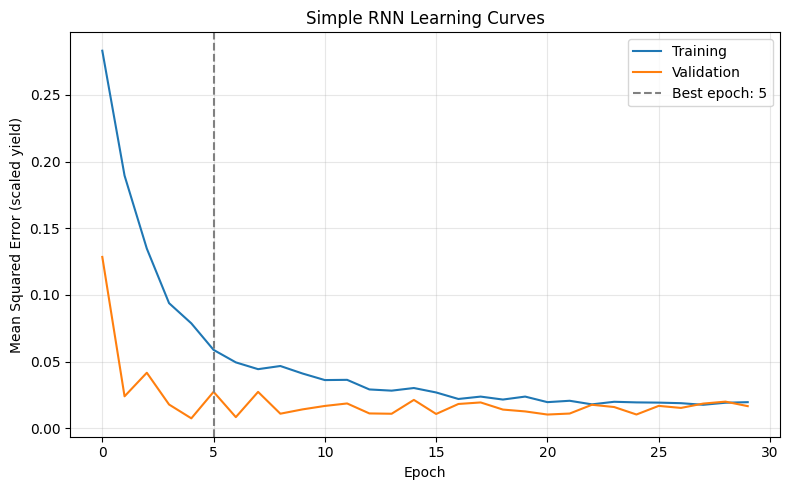

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(history_rnn.history["loss"], label="Training")
plt.plot(history_rnn.history["val_loss"], label="Validation")

best_epoch = np.argmin(history_rnn.history["val_loss"]) + 1
plt.axvline(
    best_epoch,
    color="gray",
    linestyle="--",
    label=f"Best epoch: {best_epoch}"
)

plt.title("Simple RNN Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (scaled yield)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Evaluate Simple RNN on Training and Validation Data

In [11]:
def evaluate_model(model, X_data, y_original):
    predictions_scaled = model.predict(X_data, verbose=0)
    predictions = y_scaler.inverse_transform(
        predictions_scaled
    ).ravel()

    observed = y_original.ravel()

    metrics = {
        "MAE": mean_absolute_error(observed, predictions),
        "RMSE": np.sqrt(mean_squared_error(observed, predictions)),
        "R²": r2_score(observed, predictions)
    }

    return metrics, predictions

rnn_train_metrics, rnn_train_predictions = evaluate_model(
    rnn_model, X_train, y_train_raw
)

rnn_val_metrics, rnn_val_predictions = evaluate_model(
    rnn_model, X_val, y_val_raw
)

rnn_results = pd.DataFrame(
    [rnn_train_metrics, rnn_val_metrics],
    index=["Training", "Validation"]
)

display(rnn_results.round(3))

,MAE,RMSE,R²
Training,31.030,34.762,0.165
Validation,14.745,17.665,0.771


## 12. Build the LSTM Model

In [12]:
tf.keras.utils.set_random_seed(SEED)

lstm_model = Sequential([
    Input(shape=(time_steps, n_features)),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(1, activation="linear")
], name="LSTM")

lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 11, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,649 (123.63 KB)

 Trainable params: 31,649 (123.63 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Train the LSTM Model

In [13]:
lstm_callbacks = [
    ModelCheckpoint(
        "best_model_LSTM.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )
]

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    shuffle=True,
    callbacks=lstm_callbacks,
    verbose=2
)

print("\nEpochs completed:", len(history_lstm.history["loss"]))
print("Best epoch:", np.argmin(history_lstm.history["val_loss"]) + 1)

Epoch 1/200
19/19 - 7s - 360ms/step - loss: 0.0426 - mae: 0.1658 - val_loss: 0.0237 - val_mae: 0.1339 - learning_rate: 0.0010
Epoch 2/200
19/19 - 0s - 11ms/step - loss: 0.0223 - mae: 0.1181 - val_loss: 0.0254 - val_mae: 0.1417 - learning_rate: 0.0010
Epoch 3/200
19/19 - 0s - 13ms/step - loss: 0.0199 - mae: 0.1125 - val_loss: 0.0085 - val_mae: 0.0800 - learning_rate: 0.0010
Epoch 4/200
19/19 - 0s - 15ms/step - loss: 0.0171 - mae: 0.1038 - val_loss: 0.0085 - val_mae: 0.0797 - learning_rate: 0.0010
Epoch 5/200
19/19 - 0s - 15ms/step - loss: 0.0154 - mae: 0.0983 - val_loss: 0.0062 - val_mae: 0.0673 - learning_rate: 0.0010
Epoch 6/200
19/19 - 0s - 11ms/step - loss: 0.0131 - mae: 0.0908 - val_loss: 0.0101 - val_mae: 0.0895 - learning_rate: 0.0010
Epoch 7/200
19/19 - 0s - 11ms/step - loss: 0.0136 - mae: 0.0915 - val_loss: 0.0131 - val_mae: 0.1026 - learning_rate: 0.0010
Epoch 8/200
19/19 - 0s - 11ms/step - loss: 0.0131 - mae: 0.0906 - val_loss: 0.0077 - val_mae: 0.0766 - learning_rate: 0.0010

## 14. Plot Learning Curves and Evaluate the LSTM

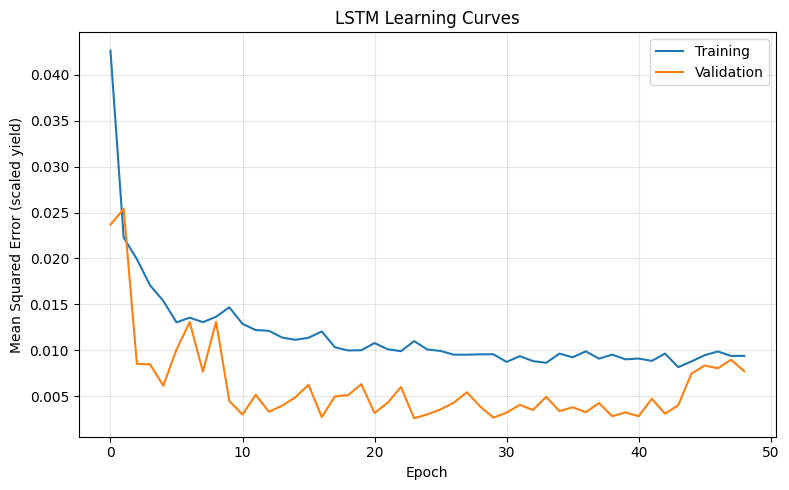

,MAE,RMSE,R²
Training,14.762,18.612,0.761
Validation,8.140,10.540,0.918


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history_lstm.history["loss"], label="Training")
plt.plot(history_lstm.history["val_loss"], label="Validation")
plt.title("LSTM Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (scaled yield)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

lstm_train_metrics, lstm_train_predictions = evaluate_model(
    lstm_model, X_train, y_train_raw
)

lstm_val_metrics, lstm_val_predictions = evaluate_model(
    lstm_model, X_val, y_val_raw
)

lstm_results = pd.DataFrame(
    [lstm_train_metrics, lstm_val_metrics],
    index=["Training", "Validation"]
)

display(lstm_results.round(3))

## 15. Build the GRU Model

In [15]:
tf.keras.utils.set_random_seed(SEED)

gru_model = Sequential([
    Input(shape=(time_steps, n_features)),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32),
    Dropout(0.2),
    Dense(1, activation="linear")
], name="GRU")

gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

gru_model.summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 11, 64)         │        14,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,033 (93.88 KB)

 Trainable params: 24,033 (93.88 KB)

 Non-trainable params: 0 (0.00 B)

## 16. Train the GRU Model

In [16]:
gru_callbacks = [
    ModelCheckpoint(
        "best_model_GRU.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=0
    ),
    EarlyStopping(
        monitor="val_loss",
        patience=25,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=10,
        min_lr=1e-5
    )
]

history_gru = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    shuffle=True,
    callbacks=gru_callbacks,
    verbose=2
)

print("\nEpochs completed:", len(history_gru.history["loss"]))
print("Best epoch:", np.argmin(history_gru.history["val_loss"]) + 1)

Epoch 1/200
19/19 - 5s - 270ms/step - loss: 0.1005 - mae: 0.2468 - val_loss: 0.0949 - val_mae: 0.2737 - learning_rate: 0.0010
Epoch 2/200
19/19 - 0s - 14ms/step - loss: 0.0384 - mae: 0.1602 - val_loss: 0.0252 - val_mae: 0.1367 - learning_rate: 0.0010
Epoch 3/200
19/19 - 0s - 14ms/step - loss: 0.0270 - mae: 0.1319 - val_loss: 0.0148 - val_mae: 0.1056 - learning_rate: 0.0010
Epoch 4/200
19/19 - 0s - 13ms/step - loss: 0.0213 - mae: 0.1170 - val_loss: 0.0131 - val_mae: 0.0972 - learning_rate: 0.0010
Epoch 5/200
19/19 - 0s - 13ms/step - loss: 0.0192 - mae: 0.1106 - val_loss: 0.0104 - val_mae: 0.0874 - learning_rate: 0.0010
Epoch 6/200
19/19 - 0s - 13ms/step - loss: 0.0160 - mae: 0.1004 - val_loss: 0.0059 - val_mae: 0.0658 - learning_rate: 0.0010
Epoch 7/200
19/19 - 0s - 11ms/step - loss: 0.0159 - mae: 0.0991 - val_loss: 0.0072 - val_mae: 0.0721 - learning_rate: 0.0010
Epoch 8/200
19/19 - 0s - 11ms/step - loss: 0.0136 - mae: 0.0911 - val_loss: 0.0066 - val_mae: 0.0689 - learning_rate: 0.0010

## 17. Plot Learning Curves and Evaluate the GRU

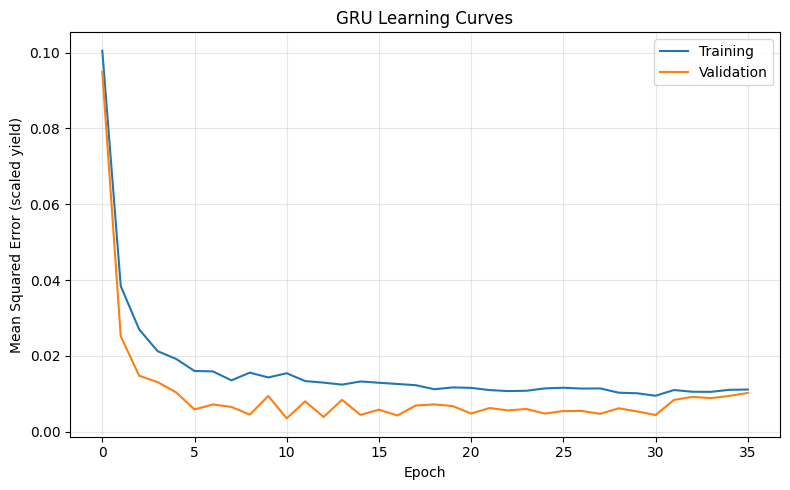

,MAE,RMSE,R²
Training,16.198,20.266,0.716
Validation,10.222,12.258,0.890


In [17]:
plt.figure(figsize=(8, 5))
plt.plot(history_gru.history["loss"], label="Training")
plt.plot(history_gru.history["val_loss"], label="Validation")
plt.title("GRU Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (scaled yield)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

gru_train_metrics, gru_train_predictions = evaluate_model(
    gru_model, X_train, y_train_raw
)

gru_val_metrics, gru_val_predictions = evaluate_model(
    gru_model, X_val, y_val_raw
)

gru_results = pd.DataFrame(
    [gru_train_metrics, gru_val_metrics],
    index=["Training", "Validation"]
)

display(gru_results.round(3))

## 18. Compare Models on the Test Set

In [18]:
models = {
    "Simple RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

test_predictions = {}
test_results = []

for name, model in models.items():
    metrics, predictions = evaluate_model(
        model, X_test, y_test_raw
    )

    test_predictions[name] = predictions
    test_results.append({
        "Model": name,
        **metrics
    })

comparison = (
    pd.DataFrame(test_results)
    .set_index("Model")
    .sort_values("RMSE")
)

display(comparison.round(3))

,MAE,RMSE,R²
Model,,,
LSTM,15.700,18.279,0.699
GRU,15.682,18.392,0.696
Simple RNN,16.826,23.086,0.521


## 19. Plot Observed versus Predicted Test Yield

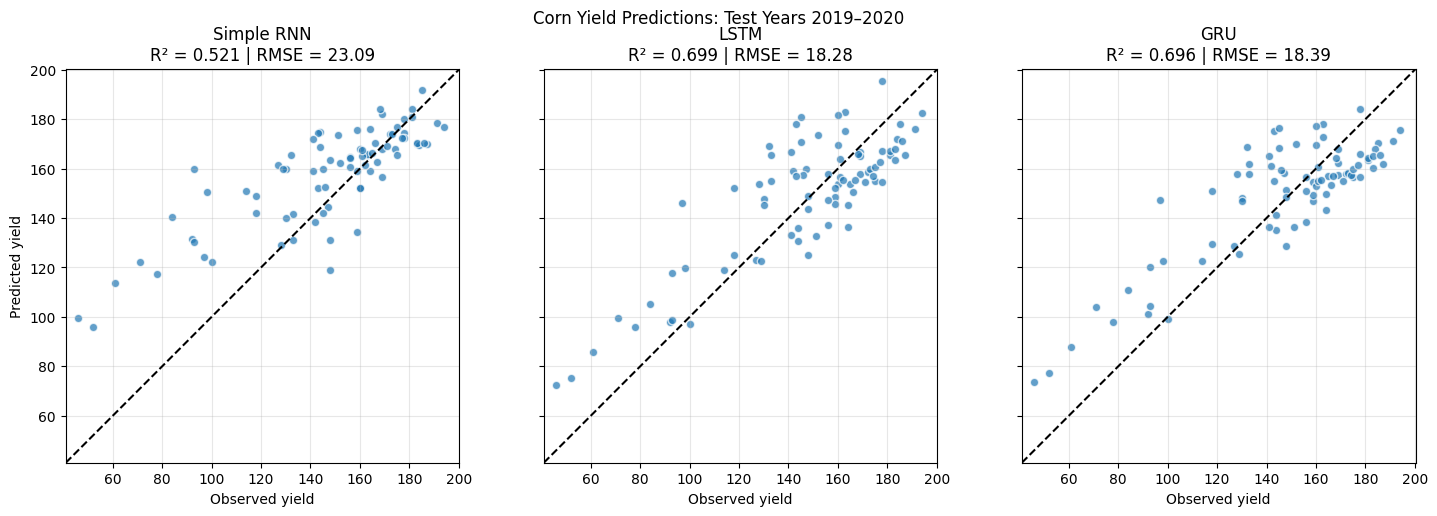

In [19]:
observed = y_test_raw.ravel()

all_values = np.concatenate([
    observed,
    *test_predictions.values()
])
limits = [all_values.min() - 5, all_values.max() + 5]

fig, axes = plt.subplots(
    1, 3, figsize=(15, 5), sharex=True, sharey=True
)

for ax, (name, predictions) in zip(
    axes, test_predictions.items()
):
    metrics = comparison.loc[name]

    ax.scatter(
        observed, predictions,
        alpha=0.7, edgecolors="white"
    )
    ax.plot(limits, limits, "k--")
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(
        f"{name}\n"
        f"R² = {metrics['R²']:.3f} | "
        f"RMSE = {metrics['RMSE']:.2f}"
    )
    ax.set_xlabel("Observed yield")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Predicted yield")
fig.suptitle("Corn Yield Predictions: Test Years 2019–2020")
plt.tight_layout()
plt.show()